In [1]:
# Import libraries for clustering, plotting, and text/vector pipeline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import ast
import os

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

In [2]:
# Load the final SVD feature table from the SVD notebook.
# This table already contains the reduced semantic vectors: SV_1 to SV_998.

svd_df = pd.read_csv("../brit/balanced_svd_table.csv")

print("SVD table shape:", svd_df.shape)
print("Columns:", svd_df.columns[:10].tolist(), "...")

svd_df.head()

SVD table shape: (5000, 1004)
Columns: ['name', 'Average', 'number_of_reviews', 'class', 'boardgamecategory', 'boardgamemechanic', 'SV_1', 'SV_2', 'SV_3', 'SV_4'] ...


,name,Average,number_of_reviews,class,boardgamecategory,boardgamemechanic,SV_1,SV_2,SV_3,SV_4,...,SV_989,SV_990,SV_991,SV_992,SV_993,SV_994,SV_995,SV_996,SV_997,SV_998
0,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],0.180557,-0.068886,0.598678,0.18629,...,-0.000026,0.000151,0.000064,0.000058,-0.000147,0.000030,-0.000101,0.000129,0.000019,-0.000011
1,Oneupmanship: Mine's Bigger,1.04,75,1,"['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El...",0.143434,-0.065287,0.388869,-0.66626,...,0.000109,-0.000020,-0.000129,0.000087,0.000176,0.000027,0.000177,0.000001,-0.000032,0.000040
2,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],0.180557,-0.068886,0.598678,0.18629,...,-0.000026,0.000151,0.000064,0.000058,-0.000147,0.000030,-0.000101,0.000129,0.000019,-0.000011
3,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],0.180557,-0.068886,0.598678,0.18629,...,-0.000026,0.000151,0.000064,0.000058,-0.000147,0.000030,-0.000101,0.000129,0.000019,-0.000011
4,Oneupmanship: Mine's Bigger,1.04,75,1,"['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El...",0.143434,-0.065287,0.388869,-0.66626,...,0.000109,-0.000020,-0.000129,0.000087,0.000176,0.000027,0.000177,0.000001,-0.000032,0.000040


In [21]:
# Select only the SVD feature columns.
# These are the numerical semantic vectors used for clustering.
# We do not cluster using name, score, reviews, category, or mechanics.

sv_cols = [col for col in svd_df.columns if col.startswith("SV_")]

X_svd = svd_df[sv_cols].values

print("Number of SVD columns:", len(sv_cols))
print("X_svd shape:", X_svd.shape)

Number of SVD columns: 998
X_svd shape: (5000, 998)


In [22]:
# Run KMeans to create broad game clusters.
# k=5 is a reasonable starting point for market segments.

k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

svd_df["kmeans_cluster"] = kmeans.fit_predict(X_svd)

print("KMeans cluster counts:")
print(svd_df["kmeans_cluster"].value_counts().sort_index())

KMeans cluster counts:
kmeans_cluster
0      96
1     238
2     262
3    4237
4     167
Name: count, dtype: int64


In [23]:
# Evaluate the KMeans clusters.
# Higher silhouette score is better.
# Lower Davies-Bouldin score is better.

sil_score = silhouette_score(X_svd, svd_df["kmeans_cluster"])
db_score = davies_bouldin_score(X_svd, svd_df["kmeans_cluster"])

print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Score: {db_score:.4f}")

Silhouette Score: 0.1798
Davies-Bouldin Score: 0.9229


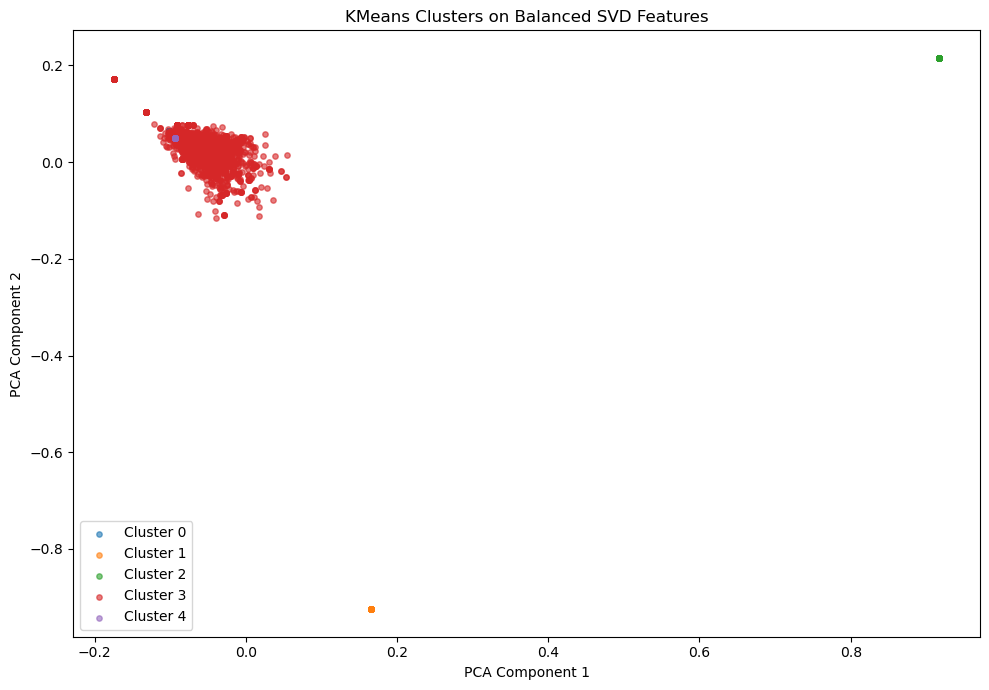

In [24]:
# PCA is only used here to reduce the 998 SVD features into 2 dimensions for plotting.
# This does not change the actual KMeans clustering.

pca = PCA(n_components=2, random_state=42)
X_plot = pca.fit_transform(X_svd)

svd_df["plot_x"] = X_plot[:, 0]
svd_df["plot_y"] = X_plot[:, 1]

plt.figure(figsize=(10, 7))

for cluster_id in sorted(svd_df["kmeans_cluster"].unique()):
    cluster_data = svd_df[svd_df["kmeans_cluster"] == cluster_id]
    plt.scatter(
        cluster_data["plot_x"],
        cluster_data["plot_y"],
        label=f"Cluster {cluster_id}",
        alpha=0.6,
        s=15
    )

plt.title("KMeans Clusters on Balanced SVD Features")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# The category and mechanic columns are stored like text versions of Python lists.
# This function converts them into actual lists.

def parse_list_column(value):
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return parsed
        return []
    except:
        return []

In [26]:
# This summarizes each KMeans cluster using:
# - count of games
# - average score
# - most common categories
# - most common mechanics
# - sample game titles

def summarize_kmeans_clusters(df, top_n=5):
    summaries = []

    for cluster_id in sorted(df["kmeans_cluster"].unique()):
        cluster_df = df[df["kmeans_cluster"] == cluster_id].copy()

        categories = []
        mechanics = []

        for item in cluster_df["boardgamecategory"].dropna():
            categories.extend(parse_list_column(item))

        for item in cluster_df["boardgamemechanic"].dropna():
            mechanics.extend(parse_list_column(item))

        top_categories = pd.Series(categories).value_counts().head(top_n).index.tolist()
        top_mechanics = pd.Series(mechanics).value_counts().head(top_n).index.tolist()
        sample_games = cluster_df["name"].head(top_n).tolist()

        summaries.append({
            "kmeans_cluster": cluster_id,
            "count": len(cluster_df),
            "average_score": cluster_df["Average"].mean(),
            "top_categories": top_categories,
            "top_mechanics": top_mechanics,
            "sample_games": sample_games
        })

    return pd.DataFrame(summaries)

cluster_summary = summarize_kmeans_clusters(svd_df)

cluster_summary

,kmeans_cluster,count,average_score,top_categories,top_mechanics,sample_games
0,0,96,2.140000,"[Real-time, Science Fiction]","[Auction/Bidding, Hand Management, Simultaneou...","[Time Control, Time Control, Time Control, Tim..."
1,1,238,9.570000,"[Adventure, Deduction, Dice, Exploration, Fant...","[Cooperative Game, Dice Rolling, Grid Movement...","[Malhya: Lands of Legends, Malhya: Lands of Le..."
2,2,262,9.560000,"[Adventure, Exploration, Fantasy, Miniatures]","[Action Points, Dice Rolling, Modular Board, P...","[Erune, Erune, Erune, Erune, Erune]"
3,3,4237,5.269896,"[Card Game, Wargame, Fantasy, Economic, Movies...","[Dice Rolling, Roll / Spin and Move, Hand Mana...","[Rock Paper Scissors Game, Oneupmanship: Mine'..."
4,4,167,1.480000,"[Action / Dexterity, Collectible Components, F...",[Variable Player Powers],"[BreaKey, BreaKey, BreaKey, BreaKey, BreaKey]"


In [27]:
# Add temporary names to the clusters.
# You can rename these after inspecting top categories and mechanics.

cluster_names = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3",
    4: "Cluster 4"
}

svd_df["kmeans_cluster_name"] = svd_df["kmeans_cluster"].map(cluster_names)

svd_df[["name", "Average", "kmeans_cluster", "kmeans_cluster_name"]].head()

,name,Average,kmeans_cluster,kmeans_cluster_name
0,Rock Paper Scissors Game,1.31,3,Cluster 3
1,Oneupmanship: Mine's Bigger,1.04,3,Cluster 3
2,Rock Paper Scissors Game,1.31,3,Cluster 3
3,Rock Paper Scissors Game,1.31,3,Cluster 3
4,Oneupmanship: Mine's Bigger,1.04,3,Cluster 3


In [28]:
# Run hierarchical clustering inside each KMeans cluster.
# KMeans gives broad clusters.
# Hierarchical clustering gives smaller subclusters inside each broad cluster.

svd_df["hierarchical_subcluster"] = -1

n_subclusters = 3

for cluster_id in sorted(svd_df["kmeans_cluster"].unique()):
    cluster_indices = svd_df[svd_df["kmeans_cluster"] == cluster_id].index
    X_cluster = X_svd[cluster_indices]

    # If the cluster is too small, do not split it.
    if len(cluster_indices) < n_subclusters:
        svd_df.loc[cluster_indices, "hierarchical_subcluster"] = 0
        continue

    hierarchical = AgglomerativeClustering(
        n_clusters=n_subclusters,
        linkage="ward"
    )

    subcluster_labels = hierarchical.fit_predict(X_cluster)

    svd_df.loc[cluster_indices, "hierarchical_subcluster"] = subcluster_labels

svd_df["full_cluster_label"] = (
    svd_df["kmeans_cluster"].astype(str)
    + "-"
    + svd_df["hierarchical_subcluster"].astype(str)
)

svd_df[["name", "kmeans_cluster", "hierarchical_subcluster", "full_cluster_label"]].head()

,name,kmeans_cluster,hierarchical_subcluster,full_cluster_label
0,Rock Paper Scissors Game,3,2,3-2
1,Oneupmanship: Mine's Bigger,3,1,3-1
2,Rock Paper Scissors Game,3,2,3-2
3,Rock Paper Scissors Game,3,2,3-2
4,Oneupmanship: Mine's Bigger,3,1,3-1


In [29]:
# This summarizes each smaller hierarchical subcluster.

def summarize_subclusters(df, top_n=5):
    summaries = []

    for label in sorted(df["full_cluster_label"].unique()):
        subcluster_df = df[df["full_cluster_label"] == label].copy()

        categories = []
        mechanics = []

        for item in subcluster_df["boardgamecategory"].dropna():
            categories.extend(parse_list_column(item))

        for item in subcluster_df["boardgamemechanic"].dropna():
            mechanics.extend(parse_list_column(item))

        top_categories = pd.Series(categories).value_counts().head(top_n).index.tolist()
        top_mechanics = pd.Series(mechanics).value_counts().head(top_n).index.tolist()
        sample_games = subcluster_df["name"].head(top_n).tolist()

        summaries.append({
            "full_cluster_label": label,
            "count": len(subcluster_df),
            "average_score": subcluster_df["Average"].mean(),
            "top_categories": top_categories,
            "top_mechanics": top_mechanics,
            "sample_games": sample_games
        })

    return pd.DataFrame(summaries)

subcluster_summary = summarize_subclusters(svd_df)

subcluster_summary

,full_cluster_label,count,average_score,top_categories,top_mechanics,sample_games
0,0-0,94,2.140000,"[Real-time, Science Fiction]","[Auction/Bidding, Hand Management, Simultaneou...","[Time Control, Time Control, Time Control, Tim..."
1,0-1,1,2.140000,"[Real-time, Science Fiction]","[Auction/Bidding, Hand Management, Simultaneou...",[Time Control]
2,0-2,1,2.140000,"[Real-time, Science Fiction]","[Auction/Bidding, Hand Management, Simultaneou...",[Time Control]
3,1-0,236,9.570000,"[Adventure, Deduction, Dice, Exploration, Fant...","[Cooperative Game, Dice Rolling, Grid Movement...","[Malhya: Lands of Legends, Malhya: Lands of Le..."
4,1-1,1,9.570000,"[Adventure, Deduction, Dice, Exploration, Fant...","[Cooperative Game, Dice Rolling, Grid Movement...",[Malhya: Lands of Legends]
5,1-2,1,9.570000,"[Adventure, Deduction, Dice, Exploration, Fant...","[Cooperative Game, Dice Rolling, Grid Movement...",[Malhya: Lands of Legends]
6,2-0,260,9.560000,"[Adventure, Exploration, Fantasy, Miniatures]","[Action Points, Dice Rolling, Modular Board, P...","[Erune, Erune, Erune, Erune, Erune]"
7,2-1,1,9.560000,"[Adventure, Exploration, Fantasy, Miniatures]","[Action Points, Dice Rolling, Modular Board, P...",[Erune]
8,2-2,1,9.560000,"[Adventure, Exploration, Fantasy, Miniatures]","[Action Points, Dice Rolling, Modular Board, P...",[Erune]
9,3-0,3904,5.619283,"[Card Game, Wargame, Fantasy, Movies / TV / Ra...","[Dice Rolling, Hand Management, Roll / Spin an...","[Evil Dead 2: The Official Board Game, Evil De..."


In [30]:
# This gives the highest-rated games in each broad KMeans cluster.
# These can be used as competitive benchmarks.

top_games_per_cluster = (
    svd_df
    .sort_values(["kmeans_cluster", "Average"], ascending=[True, False])
    .groupby("kmeans_cluster")
    .head(10)
)

top_games_per_cluster[[
    "kmeans_cluster",
    "name",
    "Average",
    "number_of_reviews",
    "boardgamecategory",
    "boardgamemechanic"
]]

,kmeans_cluster,name,Average,number_of_reviews,boardgamecategory,boardgamemechanic
505,0,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult..."
506,0,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult..."
519,0,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult..."
522,0,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult..."
530,0,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult..."
531,0,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult..."
535,0,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult..."
541,0,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult..."
551,0,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult..."
553,0,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult..."


In [31]:
# Representative games are the games closest to each KMeans centroid.
# These are the most "typical" examples of each cluster.

representative_games = []

for cluster_id in sorted(svd_df["kmeans_cluster"].unique()):
    cluster_indices = svd_df[svd_df["kmeans_cluster"] == cluster_id].index
    X_cluster = X_svd[cluster_indices]

    centroid = kmeans.cluster_centers_[cluster_id].reshape(1, -1)

    similarities = cosine_similarity(X_cluster, centroid).flatten()

    best_local_indices = np.argsort(similarities)[::-1][:10]
    best_global_indices = cluster_indices[best_local_indices]

    temp = svd_df.loc[best_global_indices, [
        "name",
        "Average",
        "number_of_reviews",
        "boardgamecategory",
        "boardgamemechanic",
        "kmeans_cluster",
        "kmeans_cluster_name"
    ]].copy()

    temp["similarity_to_centroid"] = similarities[best_local_indices]

    representative_games.append(temp)

representative_games_df = pd.concat(representative_games, ignore_index=True)

representative_games_df

,name,Average,number_of_reviews,boardgamecategory,boardgamemechanic,kmeans_cluster,kmeans_cluster_name,similarity_to_centroid
0,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult...",0,Cluster 0,1.000000
1,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult...",0,Cluster 0,1.000000
2,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult...",0,Cluster 0,1.000000
3,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult...",0,Cluster 0,1.000000
4,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult...",0,Cluster 0,1.000000
5,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult...",0,Cluster 0,1.000000
6,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult...",0,Cluster 0,1.000000
7,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult...",0,Cluster 0,1.000000
8,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult...",0,Cluster 0,1.000000
9,Time Control,2.14,53,"['Real-time', 'Science Fiction']","['Auction/Bidding', 'Hand Management', 'Simult...",0,Cluster 0,1.000000


In [32]:
# This function finds games similar to an existing game in the dataset.
# It uses cosine similarity between SVD vectors.

def find_similar_existing_game(game_name, top_n=10):
    matches = svd_df[
        svd_df["name"].str.contains(game_name, case=False, na=False)
    ]

    if matches.empty:
        print("No matching game found.")
        return None

    game_index = matches.index[0]
    game_vector = X_svd[game_index].reshape(1, -1)

    similarities = cosine_similarity(game_vector, X_svd).flatten()

    # Exclude the game itself
    similarities[game_index] = -1

    top_indices = np.argsort(similarities)[::-1][:top_n]

    similar_games = svd_df.loc[top_indices, [
        "name",
        "Average",
        "number_of_reviews",
        "class",
        "boardgamecategory",
        "boardgamemechanic",
        "kmeans_cluster",
        "hierarchical_subcluster",
        "full_cluster_label"
    ]].copy()

    similar_games["similarity"] = similarities[top_indices]

    print("Selected game:")
    display(svd_df.loc[[game_index], [
        "name",
        "Average",
        "number_of_reviews",
        "class",
        "boardgamecategory",
        "boardgamemechanic",
        "kmeans_cluster",
        "hierarchical_subcluster",
        "full_cluster_label"
    ]])

    return similar_games

In [33]:
# test it

find_similar_existing_game("Rock Paper Scissors", top_n=10)

Selected game:


,name,Average,number_of_reviews,class,boardgamecategory,boardgamemechanic,kmeans_cluster,hierarchical_subcluster,full_cluster_label
0,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],3,2,3-2


,name,Average,number_of_reviews,class,boardgamecategory,boardgamemechanic,kmeans_cluster,hierarchical_subcluster,full_cluster_label,similarity
100,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],3,2,3-2,1.0
160,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],3,2,3-2,1.0
405,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],3,2,3-2,1.0
174,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],3,2,3-2,1.0
499,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],3,2,3-2,1.0
408,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],3,2,3-2,1.0
110,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],3,2,3-2,1.0
172,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],3,2,3-2,1.0
113,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],3,2,3-2,1.0
161,Rock Paper Scissors Game,1.31,31,1,['Action / Dexterity'],['Rock-Paper-Scissors'],3,2,3-2,1.0


In [34]:
# Save the final clustering results and summaries.

svd_df.to_csv("balanced_svd_with_clusters.csv", index=False)
cluster_summary.to_csv("kmeans_cluster_summary.csv", index=False)
subcluster_summary.to_csv("hierarchical_subcluster_summary.csv", index=False)
representative_games_df.to_csv("representative_games_per_cluster.csv", index=False)
top_games_per_cluster.to_csv("top_games_per_cluster.csv", index=False)

print("Saved clustering output files.")

Saved clustering output files.


In [35]:
# Check file sizes before pushing to GitHub.

output_files = [
    "balanced_svd_with_clusters.csv",
    "kmeans_cluster_summary.csv",
    "hierarchical_subcluster_summary.csv",
    "representative_games_per_cluster.csv",
    "top_games_per_cluster.csv"
]

for file_name in output_files:
    if os.path.exists(file_name):
        size_mb = os.path.getsize(file_name) / (1024 * 1024)
        print(f"{file_name}: {size_mb:.2f} MB")
    else:
        print(f"{file_name} not found.")

balanced_svd_with_clusters.csv: 95.13 MB
kmeans_cluster_summary.csv: 0.00 MB
hierarchical_subcluster_summary.csv: 0.00 MB
representative_games_per_cluster.csv: 0.01 MB
top_games_per_cluster.csv: 0.99 MB
